# Monthly Milk Production Forecasting
## Using RNN, LSTM, and GRU Deep Learning Models

### Business Problem
From the file name monthly_milk_production.csv, it is clear that this dataset showing the monthly milk production of a dairy farm or industry.

### Objective
The objective is to develop a time series forecasting model that accurately predicts the monthly milk production for the upcoming months. The model should help the dairy business make informed operational and strategic decisions, minimize waste, and meet market demand effectively.


## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

## 2. Load and Inspect the Dataset

In [2]:
df = pd.read_csv("monthly_milk_production.csv")
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print("Shape:", df.shape)
df.info()

Shape: (168, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        168 non-null    datetime64[ns]
 1   Production  168 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.8 KB


In [4]:
print("Missing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

Missing values:
Date          0
Production    0
dtype: int64

Duplicate rows: 0

Date range:
1962-01-01 00:00:00 to 1975-12-01 00:00:00


In [5]:
df["Production"].describe()

count    168.000000
mean     754.708333
std      102.204524
min      553.000000
25%      677.750000
50%      761.000000
75%      824.500000
max      969.000000
Name: Production, dtype: float64

### Initial observations

The dataset contains 168 monthly observations with two columns: Date and Production. The provided data has no missing values or duplicate rows. The production values range from 553 to 969, with a mean of approximately 754.71.

Because this is chronological time-series data, observations must remain in time order. Random shuffling will not be used when creating the training, validation, and test sets.

## 3. Exploratory Data Analysis

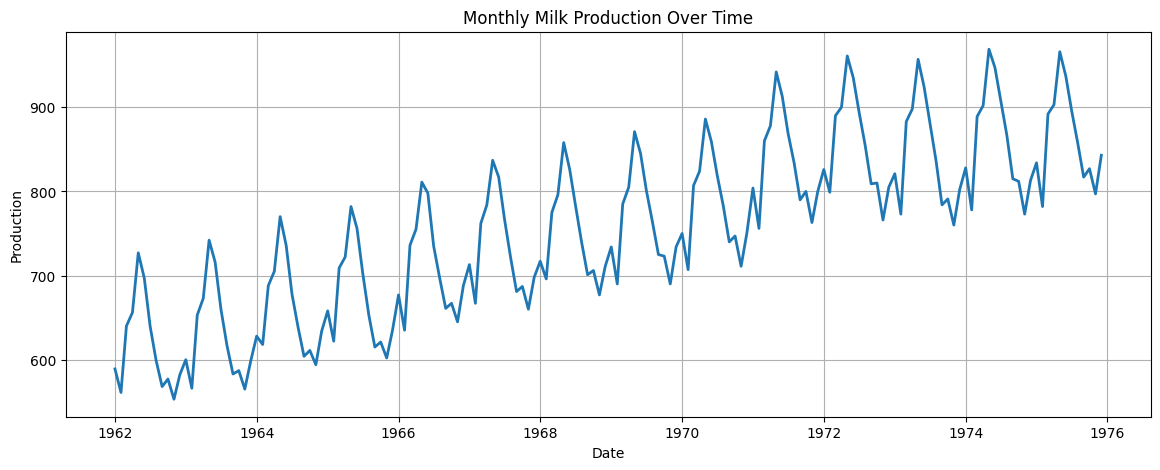

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(
    df["Date"],
    df["Production"],
    linewidth=2
)
plt.title("Monthly Milk Production Over Time")
plt.xlabel("Date")
plt.ylabel("Production")
plt.grid(True)
plt.show()

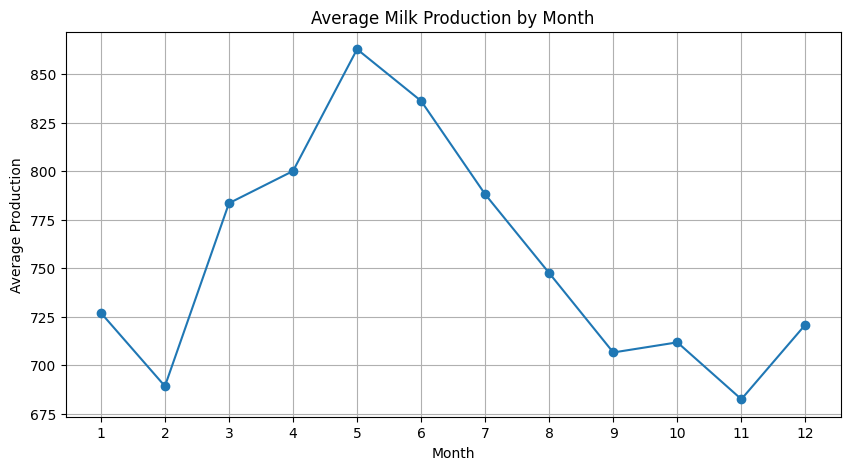

In [7]:
df["Month"] = df["Date"].dt.month
monthly_avg = df.groupby("Month")["Production"].mean()
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)
plt.title("Average Milk Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

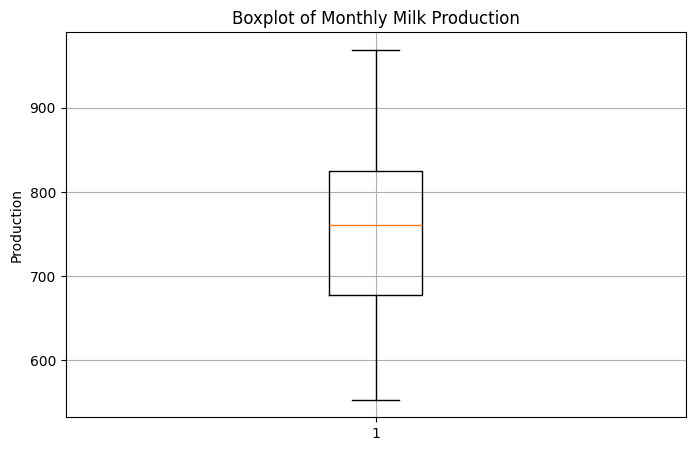

In [8]:
plt.figure(figsize=(8, 5))
plt.boxplot(df["Production"])
plt.title("Boxplot of Monthly Milk Production")
plt.ylabel("Production")
plt.grid(True)
plt.show()

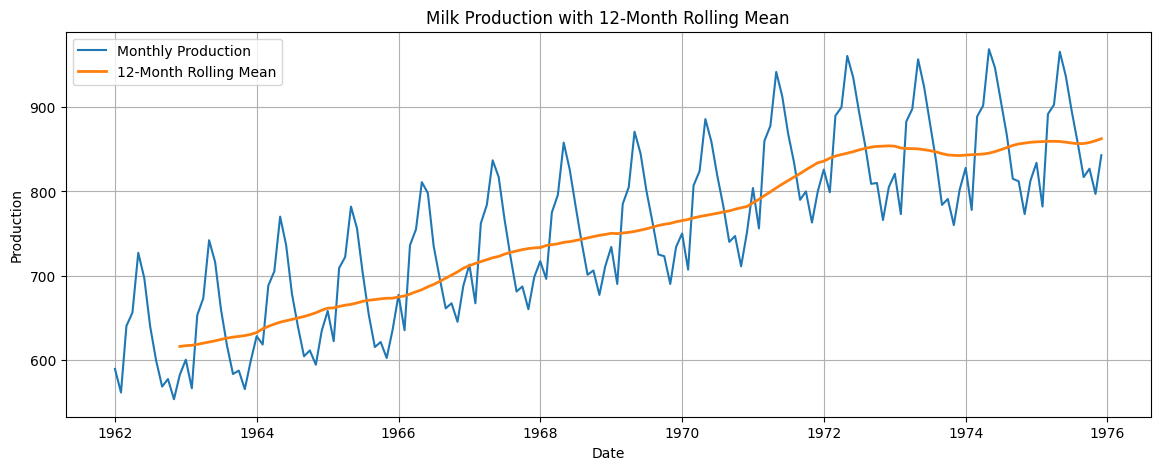

In [9]:
rolling_mean = df["Production"].rolling(window=12).mean()
plt.figure(figsize=(14, 5))
plt.plot(
    df["Date"],
    df["Production"],
    label="Monthly Production"
)
plt.plot(
    df["Date"],
    rolling_mean,
    linewidth=2,
    label="12-Month Rolling Mean"
)
plt.title("Milk Production with 12-Month Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

### EDA interpretation

The time-series plot should be used to identify long-term movement, repeated monthly behavior, and unusually high or low observations. The monthly-average plot is useful for identifying recurring seasonal patterns. The boxplot helps flag potential extreme observations, but observations should **not** be removed automatically because a high or low value may represent genuine seasonal production.

The 12-month rolling mean provides a smoother view of the underlying production pattern.


## 4. Train, Validation, and Test Split

In [10]:
values = df["Production"].values.reshape(-1, 1)
train_size = int(len(values) * 0.70)
val_size = int(len(values) * 0.15)
train_end = train_size
val_end = train_size + val_size
print("Total observations:", len(values))
print("Training observations:", train_end)
print("Validation observations:", val_end - train_end)
print("Testing observations:", len(values) - val_end)

Total observations: 168
Training observations: 117
Validation observations: 25
Testing observations: 26


## 5. Scale the Data

In [11]:
scaler = MinMaxScaler()
scaler.fit(values[:train_end])
scaled_values = scaler.transform(values)
print("Scaled minimum:", scaled_values.min())
print("Scaled maximum:", scaled_values.max())

Scaled minimum: 0.0
Scaled maximum: 1.0694087403598969


## 6. Create Time-Series Sequences

A **12-month lookback window** is used as the initial configuration. Each input contains the previous 12 months and the target is the following month.

For example:

*[Month 1 ... Month 12] -> Month 13*

The resulting neural-network input shape is:

*(samples, time_steps, features)*

where time_steps = 12 and features = 1.


In [12]:
WINDOW_SIZE = 12
def create_sequences(data, window_size):
    X = []
    y = []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i])
        y.append(data[i])
    return np.array(X), np.array(y)

In [13]:
def create_split_sequences(data, window_size, train_end, val_end):
    X_train, y_train = [], []
    X_val, y_val = [], []
    X_test, y_test = [], []
    for i in range(window_size, len(data)):
        X = data[i-window_size:i]
        y = data[i]
        if i < train_end:
            X_train.append(X)
            y_train.append(y)
        elif i < val_end:
            X_val.append(X)
            y_val.append(y)
        else:
            X_test.append(X)
            y_test.append(y)
    return (
        np.array(X_train), np.array(y_train),
        np.array(X_val), np.array(y_val),
        np.array(X_test), np.array(y_test)
    )
X_train, y_train, X_val, y_val, X_test, y_test = create_split_sequences(
    scaled_values,
    WINDOW_SIZE,
    train_end,
    val_end
)
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


X_train: (105, 12, 1)
y_train: (105, 1)
X_val: (25, 12, 1)
y_val: (25, 1)
X_test: (26, 12, 1)
y_test: (26, 1)


## 7. Model-Building Functions

To make the comparison fair and reproducible, the three models use the same general structure:

- One recurrent layer
- 64 recurrent units
- 20% dropout
- Dense hidden layer with 32 units
- One output neuron
- Adam optimizer
- Mean Squared Error (MSE) loss

Early stopping is used to reduce unnecessary training and overfitting.


In [14]:
def build_rnn(window_size, units=64, dropout=0.20):
    model = Sequential([
        Input(shape=(window_size, 1)),
        SimpleRNN(units, activation="tanh"),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(
        optimizer="adam",
        loss="mse"
    )
    return model
def build_lstm(window_size, units=64, dropout=0.20):
    model = Sequential([
        Input(shape=(window_size, 1)),
        LSTM(units, activation="tanh"),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(
        optimizer="adam",
        loss="mse"
    )
    return model
def build_gru(window_size, units=64, dropout=0.20):
    model = Sequential([
        Input(shape=(window_size, 1)),
        GRU(units, activation="tanh"),
        Dropout(dropout),
        Dense(32, activation="relu"),
        Dense(1)
    ])
    model.compile(
        optimizer="adam",
        loss="mse"
    )
    return model

## 8. Hyperparameter Tuning

In [15]:
def validation_rmse(model, X_val, y_val, scaler):
    pred_scaled = model.predict(X_val, verbose=0)
    pred = scaler.inverse_transform(pred_scaled)
    actual = scaler.inverse_transform(y_val)
    return np.sqrt(mean_squared_error(actual, pred))

In [16]:
tuning_results = []
for window in [6, 12, 18]:
    X_tr, y_tr, X_v, y_v, _, _ = create_split_sequences(
        scaled_values,
        window,
        train_end,
        val_end
    )
    for units in [32, 64]:
        for dropout in [0.10, 0.20]:
            for batch_size in [8, 16]:

                model = build_rnn(
                    window_size=window,
                    units=units,
                    dropout=dropout
                )
                callback = EarlyStopping(
                    monitor="val_loss",
                    patience=10,
                    restore_best_weights=True
                )
                model.fit(
                    X_tr,
                    y_tr,
                    validation_data=(X_v, y_v),
                    epochs=80,
                    batch_size=batch_size,
                    callbacks=[callback],
                    verbose=0
                )
                rmse = validation_rmse(
                    model,
                    X_v,
                    y_v,
                    scaler
                )
                tuning_results.append({
                    "Window": window,
                    "Units": units,
                    "Dropout": dropout,
                    "Batch Size": batch_size,
                    "Validation RMSE": rmse
                })

tuning_results = pd.DataFrame(tuning_results)
tuning_results.sort_values("Validation RMSE").head(10)

,Window,Units,Dropout,Batch Size,Validation RMSE
20,18,64,0.1,8,12.984761
7,6,64,0.2,16,13.516826
21,18,64,0.1,16,14.053925
5,6,64,0.1,16,14.942811
22,18,64,0.2,8,15.494468
23,18,64,0.2,16,16.534846
18,18,32,0.2,8,16.914065
15,12,64,0.2,16,17.620103
10,12,32,0.2,8,17.644975
17,18,32,0.1,16,17.842314


In [17]:
best_config = tuning_results.sort_values("Validation RMSE").iloc[0]
BEST_WINDOW = int(best_config["Window"])
BEST_UNITS = int(best_config["Units"])
BEST_DROPOUT = float(best_config["Dropout"])
BEST_BATCH_SIZE = int(best_config["Batch Size"])
print("Best validation configuration:")
print("Window:", BEST_WINDOW)
print("Units:", BEST_UNITS)
print("Dropout:", BEST_DROPOUT)
print("Batch size:", BEST_BATCH_SIZE)
print("Validation RMSE:", best_config["Validation RMSE"])

Best validation configuration:
Window: 18
Units: 64
Dropout: 0.1
Batch size: 8
Validation RMSE: 12.984761243841088


## 9. Recreate Sequences Using the Selected Configuration

In [18]:
X_train, y_train, X_val, y_val, X_test, y_test = create_split_sequences(
    scaled_values,
    BEST_WINDOW,
    train_end,
    val_end
)
print("Selected window size:", BEST_WINDOW)
print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Testing shape:", X_test.shape)

Selected window size: 18
Training shape: (99, 18, 1)
Validation shape: (25, 18, 1)
Testing shape: (26, 18, 1)


## 10. Train the Basic RNN

In [19]:
rnn_model = build_rnn(
    window_size=BEST_WINDOW,
    units=BEST_UNITS,
    dropout=BEST_DROPOUT
)
rnn_model.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_24 (SimpleRNN)            │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
rnn_callback = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)
history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=BEST_BATCH_SIZE,
    callbacks=[rnn_callback],
    verbose=1
)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0813 - val_loss: 0.0847
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0281 - val_loss: 0.0409
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0222 - val_loss: 0.0115
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0083 - val_loss: 0.0094
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0061 - val_loss: 0.0075
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0073 - val_loss: 0.0158
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0055 - val_loss: 0.0170
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0061 - val_loss: 0.0104
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0045 - val_loss: 0.0070
Epoch 10/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0049 - val_loss: 0.0051
Epoch 11/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0034 - val_loss: 0.0083
Epoch 12/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.

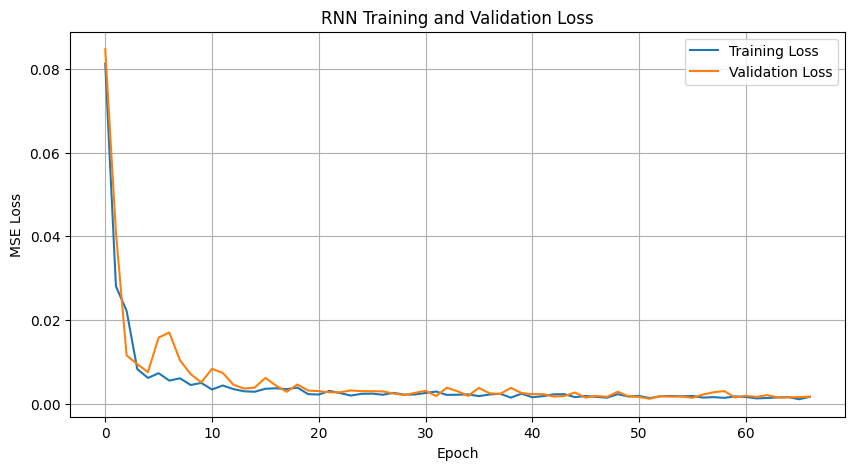

In [21]:
plt.figure(figsize=(10, 5))
plt.plot(history_rnn.history["loss"], label="Training Loss")
plt.plot(history_rnn.history["val_loss"], label="Validation Loss")
plt.title("RNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

## 11. Train the LSTM

In [22]:
lstm_model = build_lstm(
    window_size=BEST_WINDOW,
    units=BEST_UNITS,
    dropout=BEST_DROPOUT
)

lstm_model.summary()


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_51 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
lstm_callback = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=BEST_BATCH_SIZE,
    callbacks=[lstm_callback],
    verbose=1
)


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1411 - val_loss: 0.0326
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0310 - val_loss: 0.0382
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0300 - val_loss: 0.0263
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0267 - val_loss: 0.0263
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0297 - val_loss: 0.0268
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0273 - val_loss: 0.0251
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0274 - val_loss: 0.0248
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0279 - val_loss: 0.0241
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0256 - val_loss: 0.0234
Epoch 10/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0260 - val_loss: 0.0227
Epoch 11/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0254 - val_loss: 0.0222
Epoch 12/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.

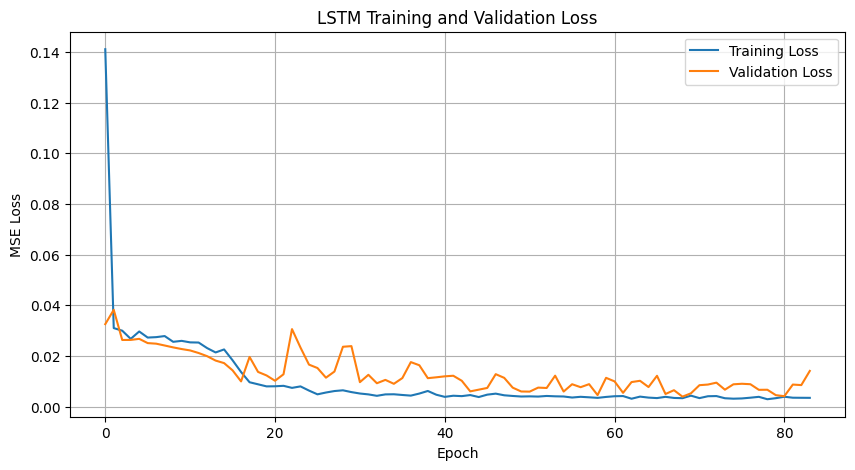

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(history_lstm.history["loss"], label="Training Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()


## 12. Train the GRU

In [25]:
gru_model = build_gru(
    window_size=BEST_WINDOW,
    units=BEST_UNITS,
    dropout=BEST_DROPOUT
)

gru_model.summary()


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 64)                  │          12,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_52 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_53 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
gru_callback = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=BEST_BATCH_SIZE,
    callbacks=[gru_callback],
    verbose=1
)


Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0692 - val_loss: 0.0240
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0267 - val_loss: 0.0320
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0226 - val_loss: 0.0241
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0220 - val_loss: 0.0234
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0194 - val_loss: 0.0199
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0185 - val_loss: 0.0198
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0149 - val_loss: 0.0163
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0176 - val_loss: 0.0172
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0155 - val_loss: 0.0152
Epoch 10/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0138 - val_loss: 0.0162
Epoch 11/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0146 - val_loss: 0.0169
Epoch 12/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - los

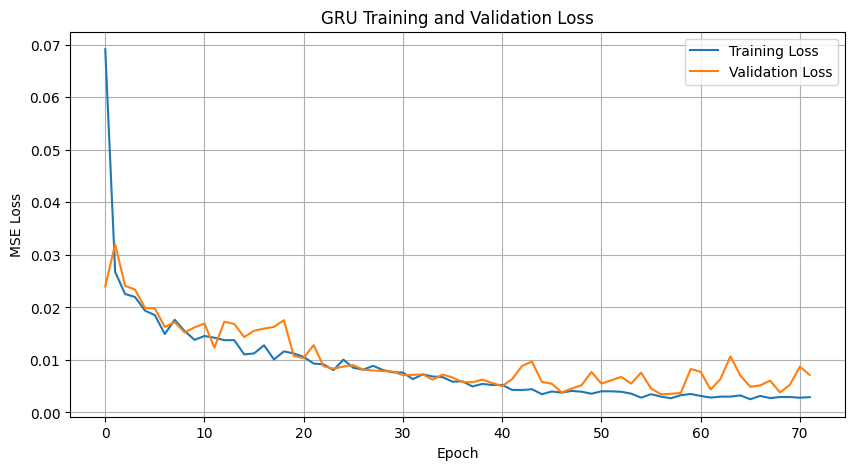

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(history_gru.history["loss"], label="Training Loss")
plt.plot(history_gru.history["val_loss"], label="Validation Loss")
plt.title("GRU Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

## 13. Generate Test-Set Predictions

In [28]:
rnn_pred_scaled = rnn_model.predict(X_test, verbose=0)
lstm_pred_scaled = lstm_model.predict(X_test, verbose=0)
gru_pred_scaled = gru_model.predict(X_test, verbose=0)
rnn_pred = scaler.inverse_transform(rnn_pred_scaled).flatten()
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
gru_pred = scaler.inverse_transform(gru_pred_scaled).flatten()
actual = scaler.inverse_transform(y_test).flatten()
test_dates = df["Date"].iloc[val_end:].reset_index(drop=True)
print("Test observations:", len(actual))

Test observations: 26


## 14. Model Evaluation — MAE, RMSE, and MAPE

In [29]:
def evaluate_model(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )
    mape = np.mean(
        np.abs((actual - predicted) / actual)
    ) * 100
    return mae, rmse, mape
rnn_metrics = evaluate_model(actual, rnn_pred)
lstm_metrics = evaluate_model(actual, lstm_pred)
gru_metrics = evaluate_model(actual, gru_pred)
results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    "MAE": [
        rnn_metrics[0],
        lstm_metrics[0],
        gru_metrics[0]
    ],
    "RMSE": [
        rnn_metrics[1],
        lstm_metrics[1],
        gru_metrics[1]
    ],
    "MAPE (%)": [
        rnn_metrics[2],
        lstm_metrics[2],
        gru_metrics[2]
    ]
})
results.sort_values("RMSE").reset_index(drop=True)

,Model,MAE,RMSE,MAPE (%)
0,RNN,12.313655,13.768836,1.438820
1,GRU,18.888144,23.620523,2.254428
2,LSTM,19.980950,26.102542,2.393386


### Metric interpretation

- **MAE:** Average absolute forecasting error in the original production units. Lower is better.
- **RMSE:** Gives greater weight to larger forecasting errors. Lower is better.
- **MAPE:** Average percentage error. Lower is better.

The model with the lowest test RMSE will be selected as the primary forecasting model, while MAE and MAPE are used as supporting metrics.


## 15. Actual vs Predicted — RNN

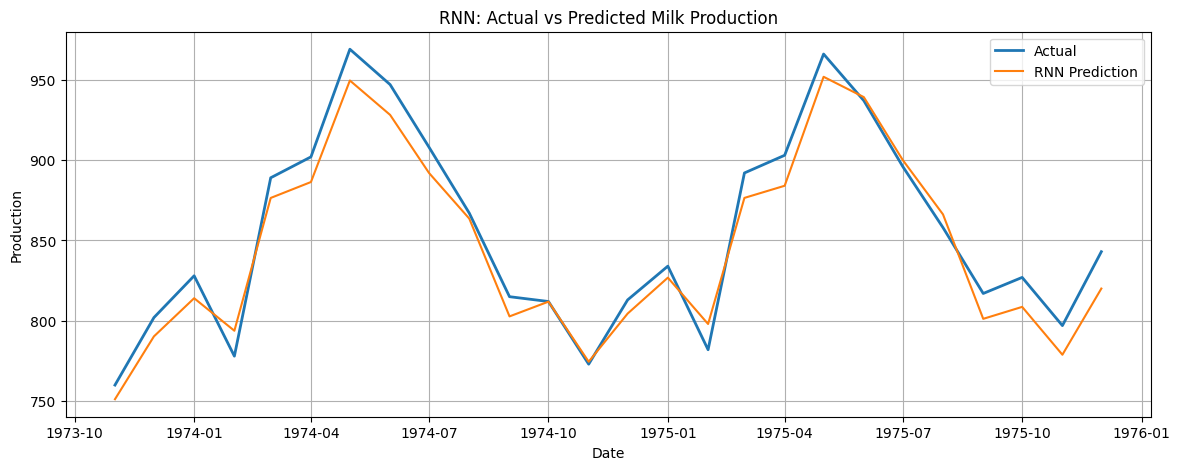

In [30]:
plt.figure(figsize=(14, 5))
plt.plot(test_dates, actual, label="Actual", linewidth=2)
plt.plot(test_dates, rnn_pred, label="RNN Prediction")
plt.title("RNN: Actual vs Predicted Milk Production")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

## 16. Actual vs Predicted — LSTM

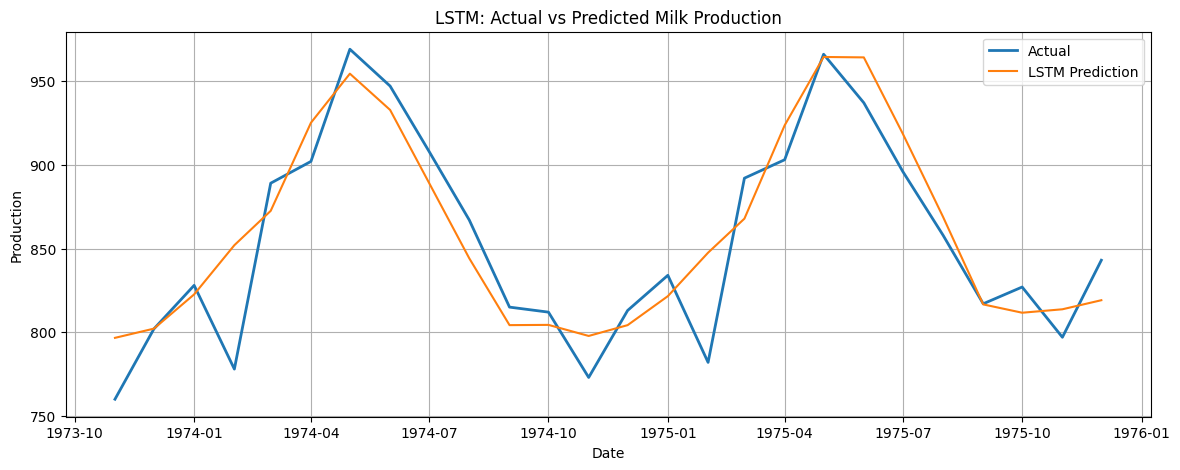

In [31]:
plt.figure(figsize=(14, 5))
plt.plot(test_dates, actual, label="Actual", linewidth=2)
plt.plot(test_dates, lstm_pred, label="LSTM Prediction")
plt.title("LSTM: Actual vs Predicted Milk Production")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

## 17. Actual vs Predicted — GRU

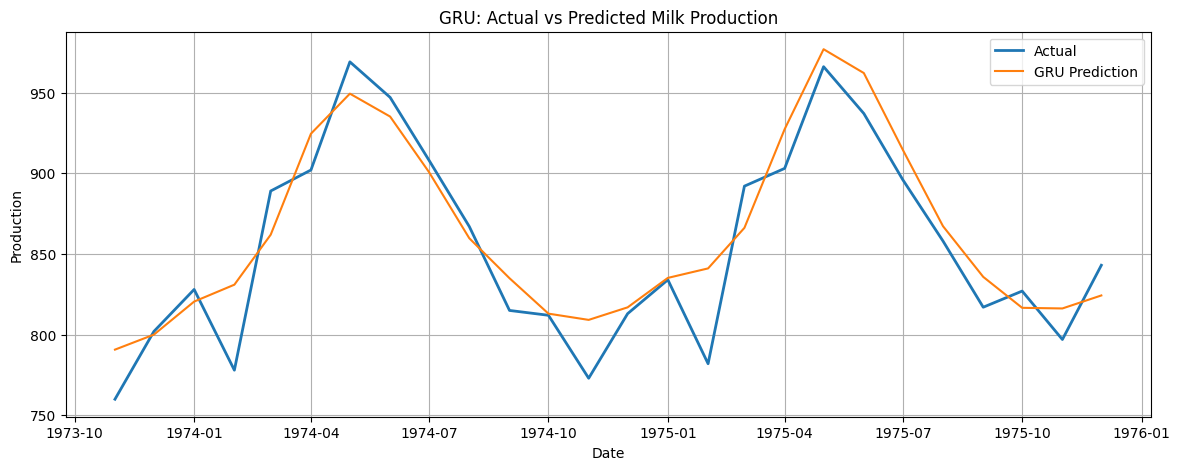

In [32]:
plt.figure(figsize=(14, 5))
plt.plot(test_dates, actual, label="Actual", linewidth=2)
plt.plot(test_dates, gru_pred, label="GRU Prediction")
plt.title("GRU: Actual vs Predicted Milk Production")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

## 18. Compare RNN, LSTM, and GRU

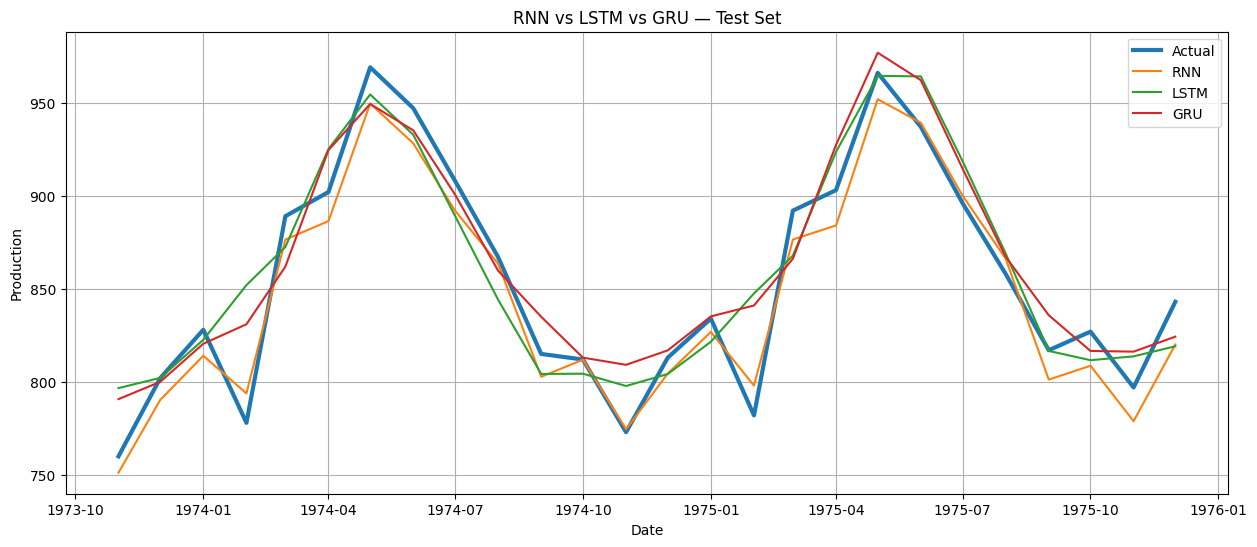

In [33]:
plt.figure(figsize=(15, 6))
plt.plot(
    test_dates,
    actual,
    label="Actual",
    linewidth=3
)
plt.plot(test_dates, rnn_pred, label="RNN")
plt.plot(test_dates, lstm_pred, label="LSTM")
plt.plot(test_dates, gru_pred, label="GRU")
plt.title("RNN vs LSTM vs GRU — Test Set")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()


## 19. Select the Best Model

In [34]:
model_objects = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}
predictions = {
    "RNN": rnn_pred,
    "LSTM": lstm_pred,
    "GRU": gru_pred
}
best_row = results.sort_values("RMSE").iloc[0]
best_model_name = best_row["Model"]
best_model = model_objects[best_model_name]
best_predictions = predictions[best_model_name]
print("Best Model:", best_model_name)
print("MAE:", round(best_row["MAE"], 4))
print("RMSE:", round(best_row["RMSE"], 4))
print("MAPE (%):", round(best_row["MAPE (%)"], 4))


Best Model: RNN
MAE: 12.3137
RMSE: 13.7688
MAPE (%): 1.4388


## 20. Forecast the Next 12 Months

The selected model is used recursively:

1. Take the most recent `BEST_WINDOW` observations.
2. Predict the next month.
3. Add the prediction to the sequence.
4. Remove the oldest observation.
5. Predict the following month.
6. Repeat for 12 months.

This produces a 12-month-ahead recursive forecast.


In [35]:
last_sequence = scaled_values[-BEST_WINDOW:].copy()
future_predictions_scaled = []
for _ in range(12):
    input_sequence = last_sequence.reshape(
        1,
        BEST_WINDOW,
        1
    )
    next_prediction = best_model.predict(
        input_sequence,
        verbose=0
    )[0, 0]
    future_predictions_scaled.append(next_prediction)
    last_sequence = np.concatenate([
        last_sequence[1:],
        np.array([[next_prediction]])
    ])
future_predictions = scaler.inverse_transform(
    np.array(future_predictions_scaled).reshape(-1, 1)
).flatten()
future_dates = pd.date_range(
    start=df["Date"].iloc[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Production": future_predictions
})
forecast_df

,Date,Forecasted_Production
0,1976-01-01,846.718567
1,1976-02-01,815.552002
2,1976-03-01,891.384094
3,1976-04-01,892.634827
4,1976-05-01,942.240417
5,1976-06-01,917.613892
6,1976-07-01,875.737549
7,1976-08-01,849.629517
8,1976-09-01,800.726379
9,1976-10-01,815.843140


## 21. Approximate Forecast Uncertainty

A neural network does not automatically produce a classical statistical prediction interval. To provide a practical indication of uncertainty, the empirical distribution of test-set residuals is used.

The interval below should therefore be described as an **approximate uncertainty interval**, not a formal statistical confidence interval.


In [36]:
residuals = actual - best_predictions
lower_residual = np.percentile(residuals, 2.5)
upper_residual = np.percentile(residuals, 97.5)
forecast_df["Lower_Bound"] = (
    forecast_df["Forecasted_Production"] + lower_residual
)
forecast_df["Upper_Bound"] = (
    forecast_df["Forecasted_Production"] + upper_residual
)
forecast_df

,Date,Forecasted_Production,Lower_Bound,Upper_Bound
0,1976-01-01,846.718567,830.835022,867.488770
1,1976-02-01,815.552002,799.668457,836.322144
2,1976-03-01,891.384094,875.500549,912.154297
3,1976-04-01,892.634827,876.751282,913.405029
4,1976-05-01,942.240417,926.356873,963.010620
5,1976-06-01,917.613892,901.730347,938.384033
6,1976-07-01,875.737549,859.854004,896.507690
7,1976-08-01,849.629517,833.745972,870.399658
8,1976-09-01,800.726379,784.842834,821.496582
9,1976-10-01,815.843140,799.959595,836.613281


## 22. Final 12-Month Forecast Visualization

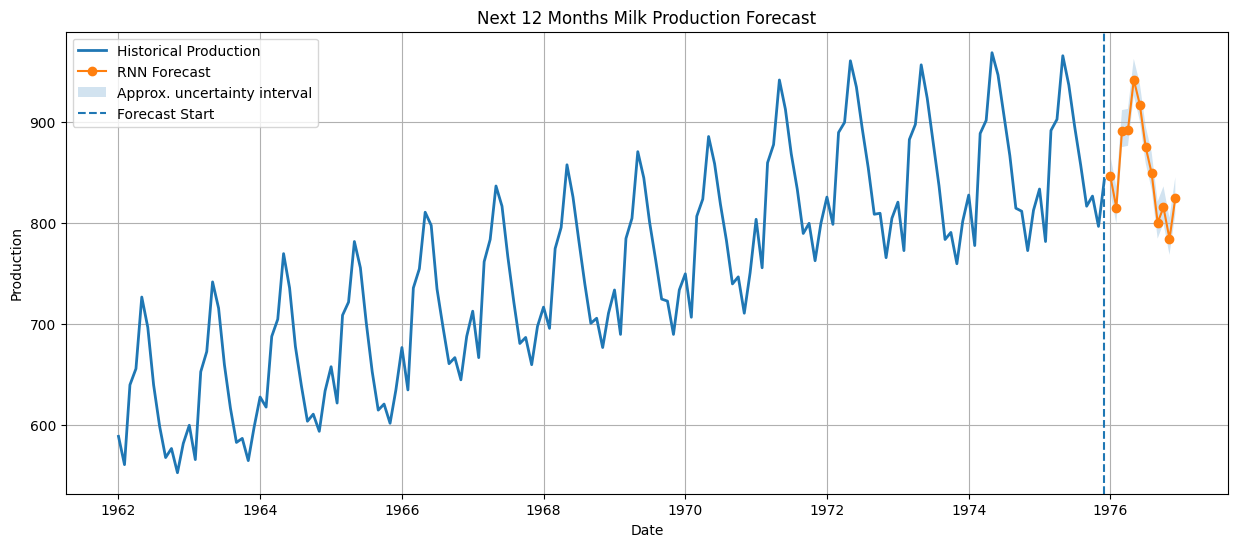

In [37]:
plt.figure(figsize=(15, 6))
plt.plot(
    df["Date"],
    df["Production"],
    label="Historical Production",
    linewidth=2
)
plt.plot(
    forecast_df["Date"],
    forecast_df["Forecasted_Production"],
    marker="o",
    label=f"{best_model_name} Forecast"
)
plt.fill_between(
    forecast_df["Date"],
    forecast_df["Lower_Bound"],
    forecast_df["Upper_Bound"],
    alpha=0.2,
    label="Approx. uncertainty interval"
)
plt.axvline(
    df["Date"].iloc[-1],
    linestyle="--",
    label="Forecast Start"
)
plt.title("Next 12 Months Milk Production Forecast")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.grid(True)
plt.show()

## 23. Business Insights

The final forecast can support the dairy business in several ways:

- **Supply-chain planning:** Estimate expected production before the upcoming months begin.
- **Inventory and storage:** Prepare adequate storage capacity during periods of higher expected production.
- **Workforce planning:** Align staffing and operational activities with expected production levels.
- **Distribution planning:** Plan transportation and distribution capacity according to forecasted output.
- **Seasonal planning:** Identify months with consistently higher or lower production and prepare resources accordingly.
- **Strategic decisions:** Use the forecast as one input when evaluating production capacity, procurement, and operational expansion.

The forecast should be updated regularly as new monthly production observations become available.


## 24. Final Conclusion

Three deep-learning time-series models — **Basic RNN, LSTM, and GRU** — were developed to forecast monthly milk production. The dataset contains 168 monthly observations and was analyzed for missing values, duplicates, trend, seasonality, and potential extreme observations.

The chronological data was divided into training, validation, and test sets. Production values were scaled using `MinMaxScaler`, with the scaler fitted only on the training data to avoid data leakage. Historical observations were converted into sequential windows for deep-learning model training.

A compact validation-based hyperparameter search was performed because the dataset is relatively small. The RNN, LSTM, and GRU models were then trained using the selected configuration and evaluated using **MAE, RMSE, and MAPE**.

The model with the lowest test RMSE was selected as the final forecasting model. It was subsequently used to generate a **12-month recursive forecast** of milk production. The forecast can assist the dairy business with supply-chain planning, inventory management, workforce allocation, distribution planning, and preparation for seasonal fluctuations.
